<a href="https://colab.research.google.com/github/vanshkothare/Machine-learning-5th-SEM-project/blob/main/PRACTICAL_NO_08_DL_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
file = "wireless_signal_hierarchical_dataset.csv"

In [ ]:
data = pd.read_csv(file)

In [ ]:
if len(data.columns) == 1:
  print("Signal column detected. Fixing CSV format...")
  data = data.iloc[:,0].str.split(
      ",", expand=True
  )


Signal column detected. Fixing CSV format...


In [ ]:
data.colomns = [
    "RSSI",
    "RSRP",
    "RSRQ",
    "Latency",
    "Packet_Loss"
]

/tmp/ipykernel_1225/3467637347.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.colomns = [


In [ ]:
print("\nDataset Preview:")
print(data.head())

print("\nDataset Columns:")
print(data.columns)




Dataset Preview:
     0    1   2   3   4  5
0  -45  -75  -5  30  10  1
1  -48  -78  -6  28  12  1
2  -50  -80  -7  27  15  2
3  -52  -82  -8  25  18  2
4  -55  -85  -9  23  20  3

Dataset Columns:
RangeIndex(start=0, stop=6, step=1)


In [ ]:
for col in data.columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data.dropna(inplace=True)

print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [ ]:
X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

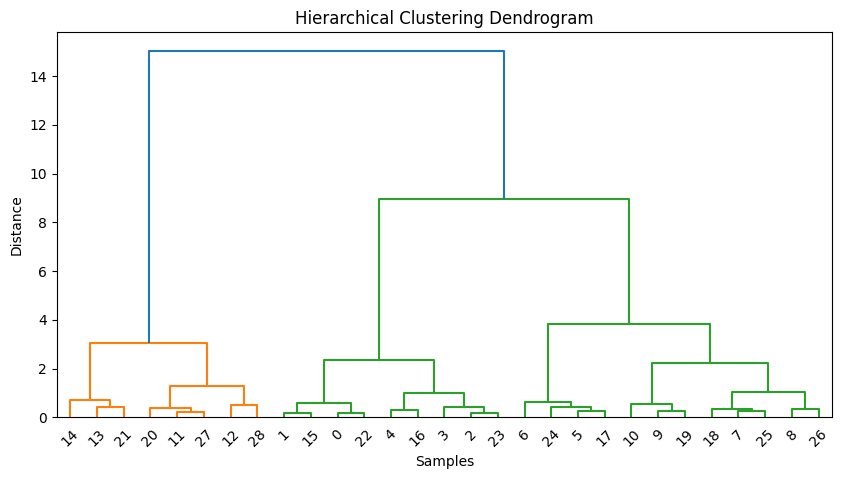

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

linked = linkage(
    X_scaled,
    method="ward"
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [ ]:
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

data["Cluster"] = model.fit_predict(X_scaled)
print("\nCluster Count:")

print(
    data["Cluster"].value_counts()
)


Cluster Count:
Cluster
0    12
2     9
1     8
Name: count, dtype: int64


In [ ]:
cluster_rssi = data.groupby(
    "Cluster"
)["RSSI"].mean()

print("\nAverage RSSI:")

print(cluster_rssi)


Average RSSI:
Cluster
0   -63.500000
1   -76.000000
2   -49.777778
Name: RSSI, dtype: float64


In [ ]:
sorted_clusters = cluster_rssi.sort_values(
    ascending=False
)

quality = {

    sorted_clusters.index[0]: "Good",

    sorted_clusters.index[1]: "Medium",

    sorted_clusters.index[2]: "Poor"
}

data["Signal_Quality"] = data["Cluster"].map(
    quality
)

In [ ]:
print("\nFinal Classification:")

print(
    data[
        [
            "RSSI",
            "RSRP",
            "SNR",
            "Cluster",
            "Signal_Quality"
        ]
    ]
)


Final Classification:
    RSSI  RSRP  SNR  Cluster Signal_Quality
0    -45   -75   30        2           Good
1    -48   -78   28        2           Good
2    -50   -80   27        2           Good
3    -52   -82   25        2           Good
4    -55   -85   23        2           Good
5    -58   -88   20        0         Medium
6    -60   -90   18        0         Medium
7    -62   -92   16        0         Medium
8    -65   -95   14        0         Medium
9    -68   -98   12        0         Medium
10   -70  -100   10        0         Medium
11   -72  -102    8        1           Poor
12   -75  -105    6        1           Poor
13   -78  -108    5        1           Poor
14   -80  -110    3        1           Poor
15   -47   -77   29        2           Good
16   -54   -84   24        2           Good
17   -59   -89   19        0         Medium
18   -64   -94   15        0         Medium
19   -69   -99   11        0         Medium
20   -74  -104    7        1           Poor
21   -79 

In [ ]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

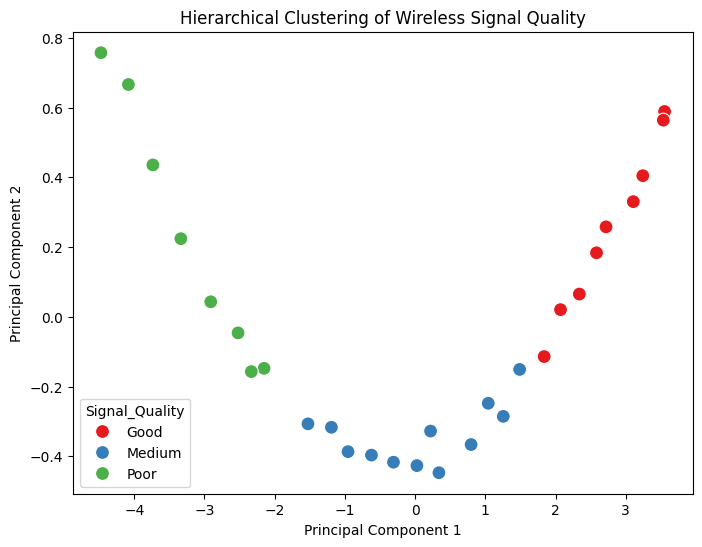

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=data["Signal_Quality"],
    palette="Set1",
    s=100
)

plt.title(
    "Hierarchical Clustering of Wireless Signal Quality"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()